In [1]:
import os
import sys

# Add your module's directory (absolute path or relative path)
module_path = os.path.abspath(os.path.join('../src')) 
if module_path not in sys.path:
    sys.path.insert(0, module_path)


In [2]:
from bandit_walk import BanditWalk
from policy_metrics import probability_success, mean_return, play_episode
from display import print_policy, print_transitions, print_state_value_function

from bandit_slippery_walk import BanditSlipperyWalk
from models import Environment
from dp import policy_improvement, policy_evaluation, policy_iteration
import random
import numpy as np

In [3]:
bandit_walk_1 = BanditWalk(n_states=3)

bandit_walk_1.P


{0: {0: [ActionResult(prob=1.0, next_state=0, reward=0.0, done=True)],
  1: [ActionResult(prob=1.0, next_state=0, reward=0.0, done=True)]},
 1: {0: [ActionResult(prob=1.0, next_state=0, reward=0.0, done=True)],
  1: [ActionResult(prob=1.0, next_state=2, reward=1.0, done=True)]},
 2: {0: [ActionResult(prob=1.0, next_state=2, reward=0.0, done=True)],
  1: [ActionResult(prob=1.0, next_state=2, reward=0.0, done=True)]}}

In [4]:
bandit_walk_1 = BanditWalk(n_states=6, start=2)

In [5]:
random_policy = lambda s: random.choice([0, 1])
print("Random Policy")
print_policy(random_policy, bandit_walk_1)

Random Policy
Policy:  (* = agent's current state)
|     H     |  01     < | *02     > |  03     < |  04     > |     G     |


In [6]:
V = policy_evaluation(env=bandit_walk_1, pi=random_policy)
print_state_value_function(V, bandit_walk_1)

State-value function:
|     H     |  01 0.000 | *02 0.000 |  03 0.000 |  04 1.000 |     G     |


In [7]:
LEFT, RIGHT = 0, 1

right_policy = lambda s: RIGHT

print("RIGHT Policy")
print_policy(right_policy, bandit_walk_1)

RIGHT Policy
Policy:  (* = agent's current state)
|     H     |  01     > | *02     > |  03     > |  04     > |     G     |


In [8]:
V = policy_evaluation(env=bandit_walk_1, pi=right_policy)
print("State Value function")
print_state_value_function(V, bandit_walk_1)

State Value function
State-value function:
|     H     |  01 0.970 | *02 0.980 |  03 0.990 |  04 1.000 |     G     |


Bandit Slippery Walk

In [9]:
slip_walk = BanditSlipperyWalk(n_states=6, start=2, goal=5, hole=0)

for state in slip_walk.P:
    for a in slip_walk.P[state]:
        print(f'State: {state}, Action: {"LEFT" if a == 0 else "RIGHT"}, Result: {slip_walk.P[state][a]}')

State: 0, Action: LEFT, Result: [ActionResult(prob=1.0, next_state=0, reward=0.0, done=True)]
State: 0, Action: RIGHT, Result: [ActionResult(prob=1.0, next_state=0, reward=0.0, done=True)]
State: 1, Action: LEFT, Result: [ActionResult(prob=0.8, next_state=0, reward=0.0, done=True), ActionResult(prob=0.2, next_state=2, reward=0.0, done=False)]
State: 1, Action: RIGHT, Result: [ActionResult(prob=0.8, next_state=2, reward=0.0, done=False), ActionResult(prob=0.2, next_state=0, reward=0.0, done=True)]
State: 2, Action: LEFT, Result: [ActionResult(prob=0.8, next_state=1, reward=0.0, done=False), ActionResult(prob=0.2, next_state=3, reward=0.0, done=False)]
State: 2, Action: RIGHT, Result: [ActionResult(prob=0.8, next_state=3, reward=0.0, done=False), ActionResult(prob=0.2, next_state=1, reward=0.0, done=False)]
State: 3, Action: LEFT, Result: [ActionResult(prob=0.8, next_state=2, reward=0.0, done=False), ActionResult(prob=0.2, next_state=4, reward=0.0, done=False)]
State: 3, Action: RIGHT, R

In [10]:
left_policy = lambda s: LEFT

In [11]:
left_V = policy_evaluation(env=slip_walk, pi=left_policy)
print_state_value_function(left_V, slip_walk)
print("Probability of success")
print(probability_success(slip_walk, left_policy))

State-value function:
|     H     |  01 0.003 | *02 0.014 |  03 0.060 |  04 0.248 |     G     |
Probability of success
0.01


In [12]:
improved_policy_1 = policy_improvement(env=slip_walk, V=left_V, gamma=0.99)
improved_V_1 = policy_evaluation(env=slip_walk, pi=improved_policy_1)
print_state_value_function(improved_V_1, slip_walk)
print("Probability of success")
print(probability_success(slip_walk, improved_policy_1))

State-value function:
| *   H     |  01 0.717 |  02 0.906 |  03 0.964 |  04 0.991 |     G     |
Probability of success
0.94


Policy Iteration

In [13]:
slip_walk.reset()
improved_policy, improved_V = policy_iteration(env=slip_walk,
                                   init_policy=left_policy)
print_state_value_function(improved_V, slip_walk)
print("Probability of success")
print(probability_success(slip_walk, improved_policy))

State-value function:
|     H     |  01 0.717 | *02 0.906 |  03 0.964 |  04 0.991 |     G     |
Probability of success
0.99


Pure Exploration Strategy

In [14]:
from dataclasses import dataclass
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from typing import Sequence

In [15]:
@dataclass
class BanditEpisodicResults:
    returns: np.ndarray
    Q_e: np.ndarray
    actions: np.ndarray
    episodes: int
    title: str

In [16]:
def pure_exploitation(env: Environment, n_episodes:int=5000):
    Q = np.zeros(len(env.actions))
    N = np.zeros(len(env.actions))

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    

    for e in range(n_episodes):
        env.reset()
        action = np.argmax(Q)
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action

    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Exploitation")



In [17]:
slip_walk_small = BanditSlipperyWalk(n_states=3, start=1, goal=2, hole=0)

In [18]:
exploitation_results = pure_exploitation(slip_walk_small)

In [19]:
def pure_exploration(env: Environment, n_episodes:int=5000):
    Q = np.zeros(len(env.actions))
    N = np.zeros(len(env.actions))

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    for e in range(n_episodes):
        env.reset()

        action = np.random.randint(len(Q))
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action

    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Exploration")

In [20]:
exploration_results = pure_exploration(slip_walk_small)

In [21]:
def epsilon_greedy(env: Environment, epsilon: float=0.01, n_episodes:int=5000):
    Q = np.zeros(len(env.actions))
    N = np.zeros(len(env.actions))

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    for e in range(n_episodes):
        env.reset()

        action = np.argmax(Q) if (np.random.random() > epsilon) else np.random.randint(len(Q))
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action
    
    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Epsilon Greedy")

In [22]:
epsilon_greedy = epsilon_greedy(env=slip_walk_small, epsilon=0.01)

In [23]:
def decay_epsilon_greedy(env: Environment, init_epsilon=1.0, decay=0.1,  min_epsilon=0.01, n_episodes:int=5000):
    Q = np.zeros(len(env.actions))
    N = np.zeros(len(env.actions))

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    for e in range(n_episodes):
        env.reset()
        decay_episodes = int(n_episodes * decay)

        eps = np.logspace(np.log10(init_epsilon), np.log10(min_epsilon), decay_episodes)
        eps = np.pad(eps, (0, n_episodes - decay_episodes), mode="edge")

        action = np.argmax(Q) if (np.random.random() > eps[e]) else np.random.randint(len(Q))
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action
    
    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Decay Epsilon")

In [24]:
decay_epsilon = decay_epsilon_greedy(slip_walk_small, decay=0.1)

In [25]:
def optimistic_initialization(env: Environment, optimistic_estimate: int=1.0, init_n:int = 10, n_episodes:int=5000):
    Q = np.ones(len(env.actions)) * optimistic_estimate
    N = np.ones(len(env.actions)) * init_n

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    for e in range(n_episodes):
        env.reset()
        
        action = np.argmax(Q)
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action
    
    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Optimisitic Initialization")

In [26]:
optimistic_initialization_results = optimistic_initialization(slip_walk_small)

In [27]:
def softmax(env: Environment, init_temp=1.0, decay=0.04,  min_temp=0.01, n_episodes:int=5000):
    Q = np.zeros(len(env.actions))
    N = np.zeros(len(env.actions))

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    for e in range(n_episodes):
        env.reset()
        decay_episodes = int(n_episodes * decay)

        temp = 1 - e / decay_episodes
        temp *= init_temp - min_temp
        temp += min_temp

        temp = np.clip(temp, min_temp, init_temp)

        scaled_Q = Q / temp
        norm_Q = scaled_Q - np.max(scaled_Q)
        exp_Q = np.exp(norm_Q)

        probs = exp_Q / np.sum(exp_Q)

        action = np.random.choice(np.arange(len(probs)), size=1, p=probs)[0]
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action
    
    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Softmax")

In [28]:
softmax_results = softmax(slip_walk_small)

In [29]:
def upper_confidence_bound(env: Environment, c: int=2, n_episodes:int=5000):
    n_arms = len(env.actions)
    Q = np.zeros(n_arms, dtype=float)
    N = np.zeros(n_arms, dtype=float)          # NOT ones -- see note above

    Q_e = np.empty((n_episodes, n_arms))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes, dtype=int)

    for e in range(n_episodes):
        env.reset()                            # fresh trial each episode
        t = e + 1                              # 1-based trial number -> ln t ok

        unplayed = N == 0
        if np.any(unplayed):
            a = int(np.flatnonzero(unplayed)[0])   # guaranteed first pull
        else:
            U = c * np.sqrt(np.log(t) / N)         # N > 0 -> finite, no warning
            a = int(np.argmax(Q + U))              # UCB1

        result = env.step(a)
        N[a] += 1
        Q[a] += (result.reward - Q[a]) / N[a]

        Q_e[e] = Q.copy()
        returns[e] = result.reward
        actions[e] = a

    return BanditEpisodicResults(returns, Q_e, actions, n_episodes,
                                 "Upper Confidence Bound")

In [30]:
ucb_results = upper_confidence_bound(slip_walk_small)

In [31]:
def thompson_sampling(env: Environment, alpha: float=1, beta:float=0, n_episodes:int=5000):
    Q = np.zeros(len(env.actions))
    N = np.ones(len(env.actions))

    Q_e = np.empty((n_episodes, len(env.actions)))
    returns = np.empty(n_episodes)
    actions = np.empty(n_episodes)

    

    for e in range(n_episodes):
        env.reset()

        samples = np.random.normal(loc=Q, scale=alpha / np.sqrt(N) + beta)

        action = np.argmax(samples)
        result = env.step(action)

        N[action] += 1

        Q[action] = Q[action] + (result.reward - Q[action]) / N[action]
        Q_e[e] = Q
        returns[e] = result.reward
        actions[e] = action

    return BanditEpisodicResults(returns, Q_e, actions, n_episodes, "Thompson Sampling")



In [32]:
thompson_sampling_results = thompson_sampling(slip_walk_small)

In [33]:
"""plot_bandit.py — unified comparison plots for bandit experiments.

One figure, three panels:

  1. Actions : groupED BAR chart. X = arm, groups = strategies.
               Bars show the fraction of episodes each strategy pulled
               each arm -- no line overlap is possible.
  2. Q       : LINES of running Q estimates (color = arm, style = strategy).
  3. Rewards : LINES (raw faint + rolling mean thick), color = strategy.

The action panel has its OWN x-axis (arm index); only the Q and reward
panels share the episodes x-axis.
"""


_STRAT_COLORS = plt.get_cmap("tab10").colors     # one per strategy
_ARM_COLORS   = plt.get_cmap("tab20").colors     # one per arm
_LINESTYLES   = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]


def _as_list(results):
    if isinstance(results, BanditEpisodicResults):
        return [results]
    return list(results)


def _strategy_labels(results, labels):
    n = len(results)
    if labels is not None:
        if len(labels) != n:
            raise ValueError(f"{len(labels)} labels for {n} results")
        return list(labels)
    return [getattr(r, "title", "") or f"strategy {i}" for i, r in enumerate(results)]


def plot_bandit_comparison(results: Sequence[BanditEpisodicResults] | BanditEpisodicResults,
                           labels: Sequence[str] | None = None,
                           arm_labels: Sequence[str] | None = None,
                           title: str = "Bandit strategies compared",
                           rolling_window: int = 100,
                           show_raw_rewards: bool = True,
                           true_values: Sequence[float] | None = None,
                           annotate_bars: bool = True,
                           figsize=(12, 10),
                           save_path: str | None = None):
    """Compare bandit strategies in a single figure.

    results      : one BanditEpisodicResults or a list of them (per strategy)
    labels       : strategy names; defaults to each result's `title`
    arm_labels   : display names for the arms, e.g. ['LEFT', 'RIGHT']
    true_values  : expected reward per arm -> dashed reference lines in Q panel
    annotate_bars: print the pull fraction on top of each bar (small problems
                   only; automatically disabled when there are many bars)
    """
    results = _as_list(results)
    n = len(results)
    names = _strategy_labels(results, labels)

    n_arms = results[0].Q_e.shape[1]
    if any(r.Q_e.shape[1] != n_arms for r in results):
        raise ValueError("all results must have the same number of arms")
    if arm_labels is None:
        arm_labels = [f"arm {i}" for i in range(n_arms)]
    if len(arm_labels) != n_arms:
        raise ValueError(f"{len(arm_labels)} arm_labels for {n_arms} arms")

    strat_colors = [_STRAT_COLORS[i % 10] for i in range(n)]
    arm_colors   = [_ARM_COLORS[a % 20] for a in range(n_arms)]
    linestyles   = [_LINESTYLES[i % len(_LINESTYLES)] for i in range(n)]

    # NOTE: do NOT share x across all three panels.
    # Only Q (panel 1) and Rewards (panel 2) share the episodes axis;
    # the Actions panel keeps its own arm-index axis.
    fig, axes = plt.subplots(3, 1, figsize=figsize,
                             sharex=False,
                             gridspec_kw={"height_ratios": [1, 1.2, 1]})
    axes[2].sharex(axes[1])                       # link episodes axis
    plt.setp(axes[1].get_xticklabels(), visible=False)  # labels only on bottom
    fig.suptitle(title, fontsize=14)

    # ==================== 1) ACTIONS: grouped bar chart =====================
    ax = axes[0]
    x = np.arange(n_arms)
    bar_width = 0.8 / n
    for i, r in enumerate(results):
        pulls = np.bincount(r.actions.astype(int), minlength=n_arms) / r.episodes
        offset = (i - (n - 1) / 2) * bar_width
        ax.bar(x + offset, pulls, bar_width,
               label=names[i], color=strat_colors[i],
               edgecolor=strat_colors[i], linewidth=1.0, alpha=0.9)

        if annotate_bars and n * n_arms <= 24:    # skip when too crowded
            for xi, pv in zip(x + offset, pulls):
                if pv > 0.02:                     # don't clutter tiny bars
                    ax.text(xi, pv + 0.02, f"{pv:.2f}", ha="center",
                            va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(arm_labels)
    ax.set_xlim(-0.6, n_arms - 0.4)               # full-width bars, own axis
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    ax.set_ylabel("fraction of pulls")
    ax.set_title("Actions pulled per strategy (fraction of episodes)")
    ax.legend(ncol=min(n, 4), fontsize=9)

    # ==================== 2) Q ESTIMATES: lines ============================
    ax = axes[1]
    for i, r in enumerate(results):
        eps = np.arange(1, r.episodes + 1)
        for a in range(n_arms):
            ax.plot(eps, r.Q_e[:, a], color=arm_colors[a],
                    linestyle=linestyles[i], linewidth=1.4, alpha=0.9)

    if true_values is not None:
        for a, tv in enumerate(true_values):
            if tv is not None:
                ax.axhline(tv, color=arm_colors[a], linestyle=":",
                           linewidth=1.0, alpha=0.5)

    ax.set_ylabel("Q estimate")
    ax.set_title("Running action-value estimates  (color = arm, linestyle = strategy)")

    arm_handles = [Line2D([0], [0], color=arm_colors[a], label=arm_labels[a])
                   for a in range(n_arms)]
    strat_handles = [Line2D([0], [0], color="gray", linestyle=linestyles[i],
                            label=names[i]) for i in range(n)]
    leg_arms = ax.legend(handles=arm_handles, loc="upper left", title="Arm",
                         fontsize=8, title_fontsize=9)
    ax.add_artist(leg_arms)
    ax.legend(handles=strat_handles, loc="upper right", title="Strategy",
              fontsize=8, title_fontsize=9)

    # ==================== 3) REWARDS: rolling mean ==========================
    ax = axes[2]
    for i, r in enumerate(results):
        eps = np.arange(1, r.episodes + 1)
        if show_raw_rewards:
            ax.plot(eps, r.returns, color=strat_colors[i], alpha=0.12,
                    linewidth=0.7, label="_nolegend_")
        if rolling_window and r.episodes >= rolling_window:
            kernel = np.ones(rolling_window) / rolling_window
            mov = np.convolve(r.returns, kernel, mode="valid")
            ax.plot(eps[rolling_window - 1:], mov, color=strat_colors[i],
                    linewidth=2.0, label=names[i])

    ax.set_xlabel("episodes")
    ax.set_ylabel("reward")
    ax.set_title("Rewards (faint = raw, thick = rolling mean)")
    ax.legend(ncol=min(n, 4), fontsize=9)

    fig.tight_layout(rect=(0, 0, 1, 0.96))
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    return fig, axes

(<Figure size 1200x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Actions pulled per strategy (fraction of episodes)'}, ylabel='fraction of pulls'>,
        <Axes: title={'center': 'Running action-value estimates  (color = arm, linestyle = strategy)'}, ylabel='Q estimate'>,
        <Axes: title={'center': 'Rewards (faint = raw, thick = rolling mean)'}, xlabel='episodes', ylabel='reward'>],
       dtype=object))

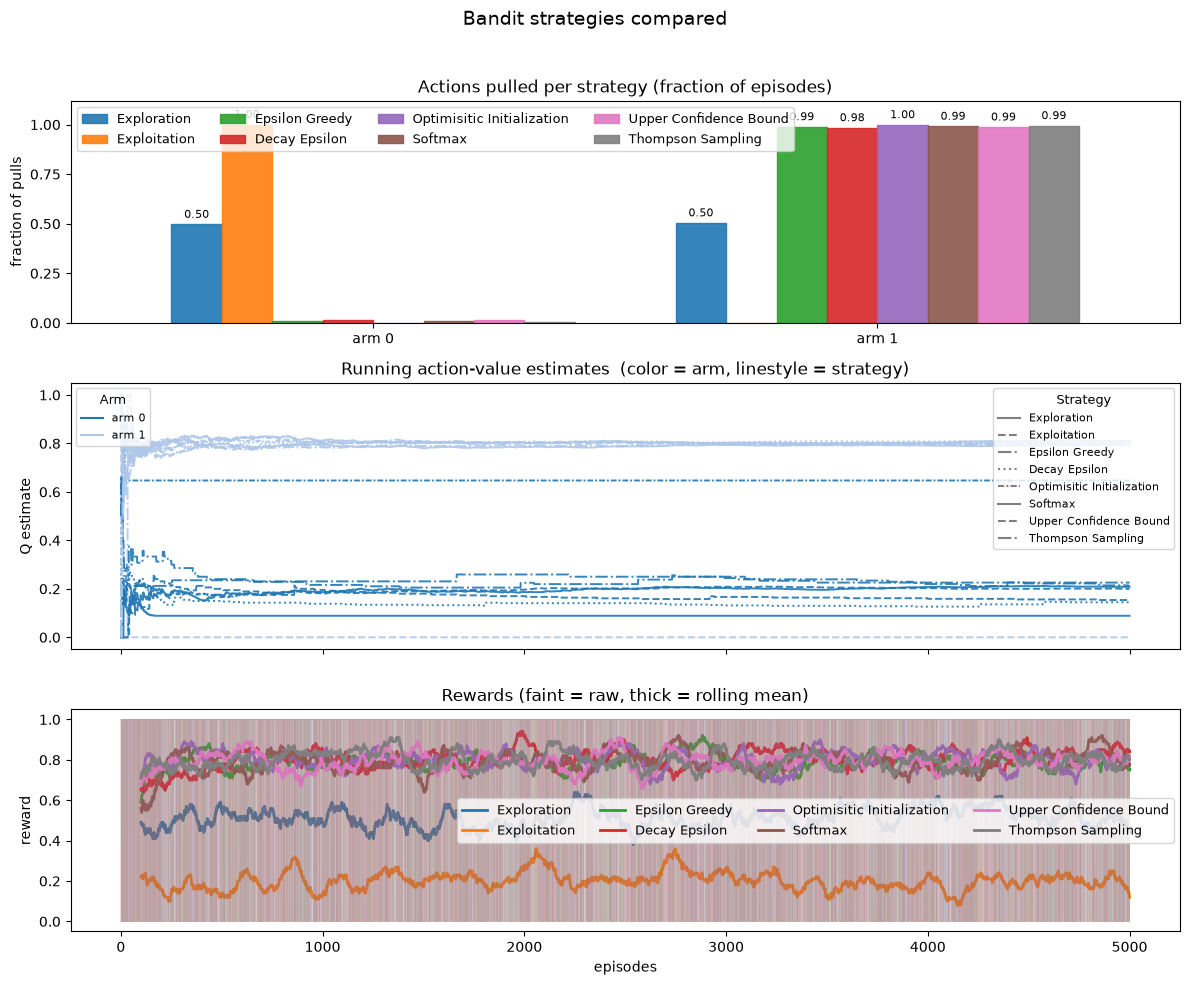

In [34]:
plot_bandit_comparison([exploration_results, exploitation_results, epsilon_greedy, decay_epsilon, optimistic_initialization_results, softmax_results, ucb_results, thompson_sampling_results])

In [35]:
from bandit_strategy import get_bandit_results, list_strategies

In [36]:
print(list_strategies())

['greedy', 'random', 'epsilon_greedy', 'decay_epsilon_greedy', 'optimistic', 'softmax', 'ucb', 'thompson']


In [37]:
results = []

results.append(get_bandit_results(slip_walk_small, "epsilon_greedy", n_episodes=5000, epsilon=0.05))
results.append(get_bandit_results(slip_walk_small, "ucb", n_episodes=5000, c=3.0))
results.append(get_bandit_results(slip_walk_small, "thompson", n_episodes=2000))
results.append(get_bandit_results(slip_walk_small, "optimistic", q_init=2.0, n_init=5))
results.append(get_bandit_results(slip_walk_small, "softmax", init_temp=1.0, decay=0.1, min_temp=0.01))
results.append(get_bandit_results(slip_walk_small, "decay_epsilon_greedy", init_epsilon=1.0, decay=0.5, min_epsilon=0.01))
results.append(get_bandit_results(slip_walk_small, "greedy"))
results.append(get_bandit_results(slip_walk_small, "random"))

(<Figure size 1200x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Actions pulled per strategy (fraction of episodes)'}, ylabel='fraction of pulls'>,
        <Axes: title={'center': 'Running action-value estimates  (color = arm, linestyle = strategy)'}, ylabel='Q estimate'>,
        <Axes: title={'center': 'Rewards (faint = raw, thick = rolling mean)'}, xlabel='episodes', ylabel='reward'>],
       dtype=object))

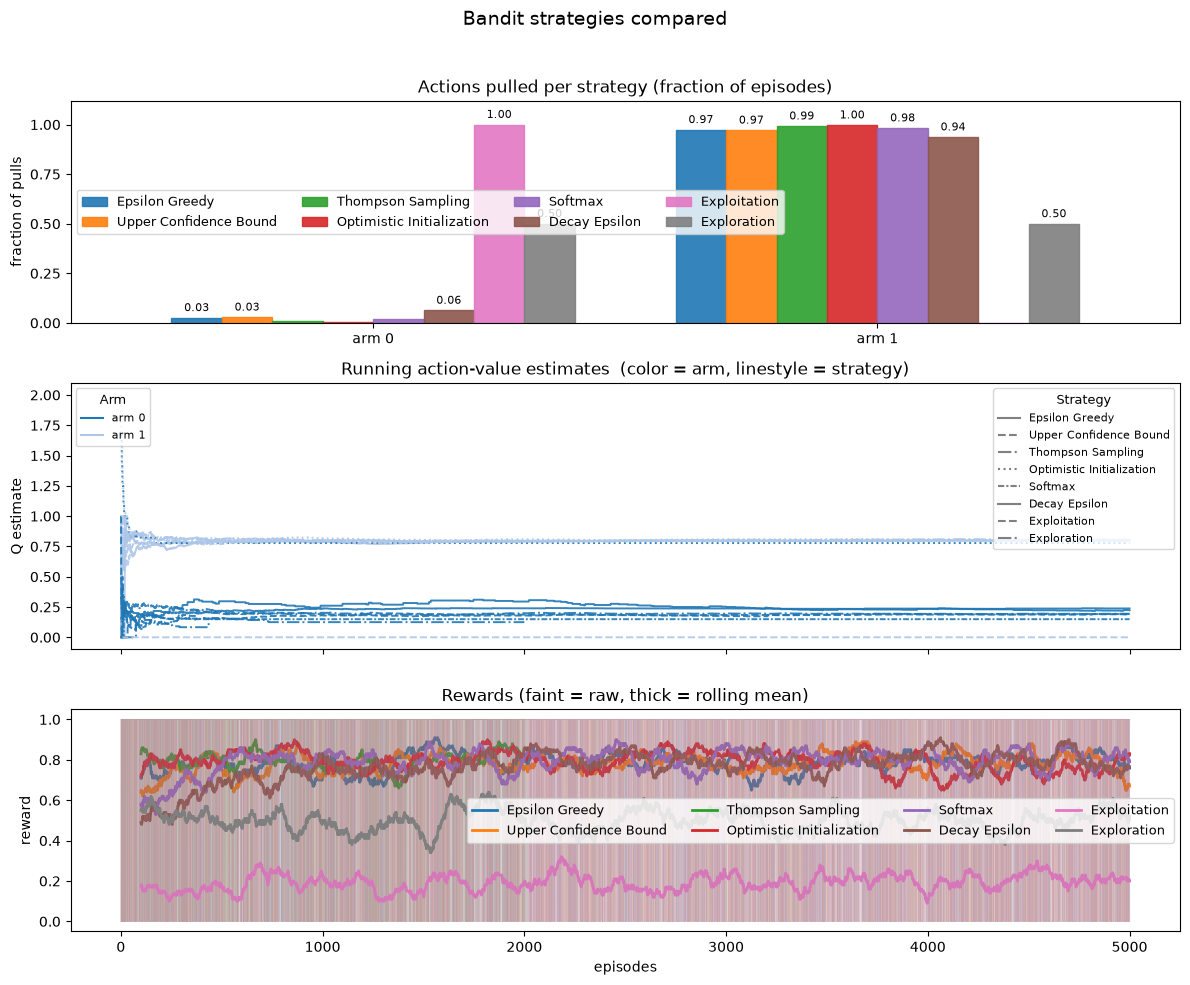

In [38]:
plot_bandit_comparison(results)